# Imports

In [48]:
import os
import sys
import json
import pickle
import datetime
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import mlflow
import optuna
from tqdm.notebook import tqdm
import sklearn.pipeline as skpipe
from sklearn.model_selection import train_test_split

# making src/ importable from the notebook
sys.path.insert(0, os.path.abspath(".."))

from src.datalib import build_engine
from src.datalib.features import extract_features
from src.datalib.transforms import LocationEncoder, FillNaTransformer
from src.model_utils import ModelKeeper

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

## Data Loading
Using the same `build_engine()` that we do in the main flow â€” ensuring consistency between training and inference.

In [49]:
# building the engine
engine = build_engine(os.path.abspath("../data"))

# loading the tables themselves
customers = engine.get_table("customers")
receipts = engine.get_table("receipts")
campaigns = engine.get_table("campaigns")

# Sanity check - we got the data
print("customers:", customers.shape)
print("receipts:", receipts.shape)
print("campaigns:", campaigns.shape)

customers: (2000000, 4)
receipts: (31741769, 5)
campaigns: (500000, 5)


## EDA: Basic Statistics

In [50]:
print("=== customers ===")
display(customers.describe())
display(customers["location"].value_counts())

print("\n=== receipts ===")
display(receipts.describe())

print("\n=== campaigns ===")
display(campaigns.describe())
print("Target group distribution:")
display(campaigns["target_group_flag"].value_counts(normalize=True))

# IMPORTANT: All campaign customers have target_group_flag = 1
# This means the campaigns table only contains TREATMENT group.
# Control group = all customers NOT in campaigns table.
print(f"\nAll campaign entries have target_group_flag=1: {(campaigns['target_group_flag'] == 1).all()}")
print(f"Campaign customers: {len(campaigns)}, Total customers: {len(customers)}")
print(f"Control group (not in campaigns): {len(customers) - len(campaigns)}")

=== customers ===


,Unnamed: 0,customer_id,age
count,2.000000e+06,2.000000e+06,2.000000e+06
mean,9.999995e+05,9.999995e+05,4.450815e+01
std,5.773504e+05,5.773504e+05,1.443533e+01
min,0.000000e+00,0.000000e+00,2.000000e+01
25%,4.999998e+05,4.999998e+05,3.200000e+01
50%,9.999995e+05,9.999995e+05,4.500000e+01
75%,1.499999e+06,1.499999e+06,5.700000e+01
max,1.999999e+06,1.999999e+06,6.900000e+01


location
Novigrad        300918
Beauclair       300689
Oxenfurt        299988
Spikeroog       299775
Hindarsfjall    299456
Kaer_Trolde     299075
Crows_perch     200099
Name: count, dtype: int64


=== receipts ===


,customer_id,date,purchase_amt,discount,purchase_sum
count,3.174177e+07,3.174177e+07,3.174177e+07,3.174177e+07,3.174177e+07
mean,9.996451e+05,1.244958e+02,1.646350e+01,2.854598e-01,1.317080e+03
std,5.775345e+05,7.213806e+01,9.322197e+00,3.367032e+00,7.457758e+02
min,0.000000e+00,0.000000e+00,1.024931e+00,0.000000e+00,8.199448e+01
25%,4.990100e+05,6.200000e+01,9.504848e+00,0.000000e+00,7.603878e+02
50%,9.990780e+05,1.240000e+02,1.478924e+01,0.000000e+00,1.183139e+03
75%,1.499913e+06,1.870000e+02,2.197335e+01,0.000000e+00,1.757868e+03
max,1.999999e+06,2.490000e+02,7.728300e+01,4.000000e+01,6.182640e+03



=== campaigns ===


,Unnamed: 0,customer_id,n_offer_days,date,target_group_flag
count,500000.000000,500000.000000,500000.0,500000.0,500000.0
mean,249999.500000,249999.500000,7.0,102.0,1.0
std,144337.711635,144337.711635,0.0,0.0,0.0
min,0.000000,0.000000,7.0,102.0,1.0
25%,124999.750000,124999.750000,7.0,102.0,1.0
50%,249999.500000,249999.500000,7.0,102.0,1.0
75%,374999.250000,374999.250000,7.0,102.0,1.0
max,499999.000000,499999.000000,7.0,102.0,1.0


Target group distribution:


target_group_flag
1    1.0
Name: proportion, dtype: float64


All campaign entries have target_group_flag=1: True
Campaign customers: 500000, Total customers: 2000000
Control group (not in campaigns): 1500000


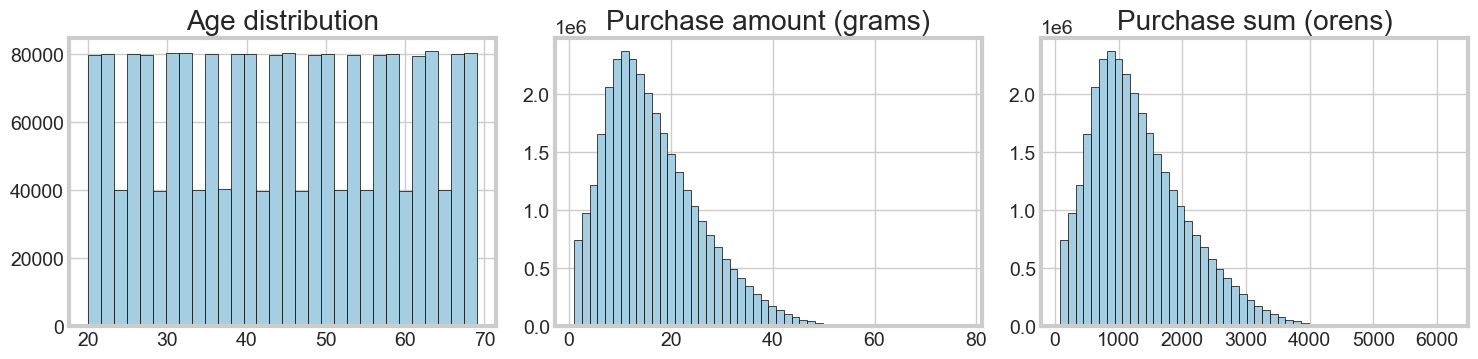

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(customers["age"], bins=30, edgecolor="k")
axes[0].set_title("Age distribution")

axes[1].hist(receipts["purchase_amt"], bins=50, edgecolor="k")
axes[1].set_title("Purchase amount (grams)")

axes[2].hist(receipts["purchase_sum"], bins=50, edgecolor="k")
axes[2].set_title("Purchase sum (orens)")

plt.tight_layout()
plt.show()

## Construct the Target Variable

**Key insight**: ALL entries in `campaigns` have `target_group_flag=1`. This means the campaigns table only records customers who **received** the offer (treatment group). Everyone else is control (target_group_flag=0).

We build the full training set by:
1. Taking ALL customers
2. Marking campaign participants as treatment (1), everyone else as control (0)
3. Computing post-campaign profit for everyone

In [52]:
COST_PER_GRAM = 52
PRICE_PER_GRAM = 80
OFFER_DAYS = 30  # evaluation horizon

# Campaign date
campaigns["date"] = pd.to_datetime(campaigns["date"])
campaign_date = campaigns["date"].min()
print("Campaign date:", campaign_date)

# Post-campaign purchases (30-day window) for ALL customers
receipts["date"] = pd.to_datetime(receipts["date"])
window_start = campaign_date
window_end = campaign_date + pd.Timedelta(days=OFFER_DAYS)

post_receipts = receipts[
    (receipts["date"] >= window_start) & (receipts["date"] < window_end)
]

# Compute profit per customer over the 30-day post-campaign window
client_revenue = (
    post_receipts
    .groupby("customer_id")
    .agg(
        total_purchased_grams=("purchase_amt", "sum"),
        total_revenue=("purchase_sum", "sum"),
    )
    .reset_index()
)
client_revenue["total_cost"] = client_revenue["total_purchased_grams"] * COST_PER_GRAM
client_revenue["gross_profit"] = client_revenue["total_revenue"] - client_revenue["total_cost"]

# Build full training set from ALL customers
# Treatment group: customers in campaigns table (target_group_flag=1)
# Control group: everyone else (target_group_flag=0)
campaign_ids = set(campaigns["customer_id"].unique())

train_data = customers[["customer_id"]].copy()
train_data["target_group_flag"] = train_data["customer_id"].isin(campaign_ids).astype(int)
train_data = train_data.merge(client_revenue, on="customer_id", how="left").fillna(0)

print(f"Train data shape: {train_data.shape}")
print(f"Treatment split: {train_data['target_group_flag'].value_counts().to_dict()}")
print(f"Treatment rate: {train_data['target_group_flag'].mean():.2%}")

Campaign date: 1970-01-01 00:00:00.000000102
Train data shape: (2000000, 6)
Treatment split: {0: 1500000, 1: 500000}
Treatment rate: 25.00%


## Feature Extraction

Using the same calcers as in the serving config (including the new ones: DoW, avg city cheque, loyalty).

In [53]:
# Features computed on data BEFORE the campaign (no leakage)
FEATURE_DATE = (campaign_date - pd.Timedelta(days=1)).date()
print("Feature date:", FEATURE_DATE)

extract_config = [
    {"name": "receipts_agg",     "args": {"delta": 60,  "date_to": FEATURE_DATE}},
    {"name": "receipts_agg",     "args": {"delta": 15,  "date_to": FEATURE_DATE}},
    {"name": "receipts_agg",     "args": {"delta": 250, "date_to": FEATURE_DATE}},
    {"name": "recency_global",   "args": {"date_to": FEATURE_DATE}},
    {"name": "purchase_trend",   "args": {"delta_short": 30, "delta_long": 120, "date_to": FEATURE_DATE}},
    {"name": "demographics",     "args": {}},
    {"name": "campaign_history", "args": {"date_to": FEATURE_DATE}},
    {"name": "day_of_week",      "args": {"date_to": FEATURE_DATE}},
    {"name": "avg_city_cheque",  "args": {"date_to": FEATURE_DATE}},
    {"name": "loyalty",          "args": {"date_to": FEATURE_DATE}},
]

raw_features = extract_features(engine, extract_config)
print("Raw features shape:", raw_features.shape)
raw_features.head()

Feature date: 1969-12-31
Raw features shape: (2000000, 56)


,customer_id,txn_count__60d,purchase_amt_sum__60d,purchase_amt_mean__60d,purchase_amt_max__60d,purchase_amt_min__60d,purchase_amt_std__60d,purchase_sum_sum__60d,purchase_sum_mean__60d,purchase_sum_max__60d,...,mode_dow,weekend_purchase_share,customer_avg_cheque,city_avg_cheque,cheque_vs_city,n_unique_days,lifespan_days,purchase_frequency,spend_per_day,loyalty_score
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Merge Features with Target + Transform

In [54]:
data = train_data.merge(raw_features, on="customer_id", how="inner")
print("Merged data shape:", data.shape)

# sklearn Pipeline for preprocessing
transform_pipeline = skpipe.Pipeline([
    ("fill_na", FillNaTransformer(fill_value=0.0)),
    ("encode_location", LocationEncoder(prefix="loc")),
])

data = transform_pipeline.fit_transform(data)
print("Transformed data shape:", data.shape)

Merged data shape: (2000000, 61)
Transformed data shape: (2000000, 67)


## Define Feature / Treatment / Target Columns

In [55]:
non_feature_cols = [
    "customer_id", "date", "n_offer_days",
    "target_group_flag",
    "total_purchased_grams", "total_revenue",
    "total_cost", "gross_profit",
]

cols_features = [c for c in data.columns if c not in non_feature_cols]
col_treatment = "target_group_flag"
col_target = "gross_profit"

print(f"Features: {len(cols_features)}")
print(cols_features)

Features: 61
['txn_count__60d', 'purchase_amt_sum__60d', 'purchase_amt_mean__60d', 'purchase_amt_max__60d', 'purchase_amt_min__60d', 'purchase_amt_std__60d', 'purchase_sum_sum__60d', 'purchase_sum_mean__60d', 'purchase_sum_max__60d', 'purchase_sum_min__60d', 'purchase_sum_std__60d', 'mean_time_interval__60d', 'recency__60d', 'txn_count__15d', 'purchase_amt_sum__15d', 'purchase_amt_mean__15d', 'purchase_amt_max__15d', 'purchase_amt_min__15d', 'purchase_amt_std__15d', 'purchase_sum_sum__15d', 'purchase_sum_mean__15d', 'purchase_sum_max__15d', 'purchase_sum_min__15d', 'purchase_sum_std__15d', 'mean_time_interval__15d', 'recency__15d', 'txn_count__250d', 'purchase_amt_sum__250d', 'purchase_amt_mean__250d', 'purchase_amt_max__250d', 'purchase_amt_min__250d', 'purchase_amt_std__250d', 'purchase_sum_sum__250d', 'purchase_sum_mean__250d', 'purchase_sum_max__250d', 'purchase_sum_min__250d', 'purchase_sum_std__250d', 'mean_time_interval__250d', 'recency__250d', 'days_since_last_purchase', 'spend

## Train/Val Split

In [56]:
fit_idx, val_idx = train_test_split(data.index, test_size=0.3, random_state=42)
print(f"Train: {len(fit_idx)}, Val: {len(val_idx)}")
print(f"Treatment rate (train): {data.loc[fit_idx, col_treatment].mean():.2%}")
print(f"Treatment rate (val):   {data.loc[val_idx, col_treatment].mean():.2%}")

Train: 1400000, Val: 600000
Treatment rate (train): 25.00%
Treatment rate (val):   25.00%


## MLflow Setup + Evaluation Helpers

In [57]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")  # or "mlruns" for file-based
mlflow.set_experiment("cunning-fox-training")

RANDOM_STATE = 42
N_TRIALS_FAST = 30    # LightGBM, XGBoost (fast learners)
N_TRIALS_MEDIUM = 20  # CatBoost, Uplift Tree
N_TRIALS_SLOW = 15    # Uplift Random Forest (expensive)

print(f"Optuna trials: fast={N_TRIALS_FAST}, medium={N_TRIALS_MEDIUM}, slow={N_TRIALS_SLOW}")

Optuna trials: fast=30, medium=20, slow=15


## Model Wrappers, Metrics & Data Preparation

Wrapper classes give every model the same `predict(X) -> (n, 1)` interface so they work with `ModelKeeper`. The **Qini coefficient** is the primary Optuna objective — it measures how well the model ranks customers by true uplift.

In [58]:
# ---- S-Learner wrapper ------------------------------------------------
class SLearnerWrapper:
    """Single model with treatment as feature. CATE = f(X,T=1) - f(X,T=0)."""
    def __init__(self, base_model, feature_cols):
        self.base_model = base_model
        self.feature_cols = feature_cols

    def predict(self, X):
        if isinstance(X, np.ndarray):
            X_arr = X
        else:
            X_arr = X[self.feature_cols].values
        X1 = np.column_stack([X_arr, np.ones(len(X_arr))])
        X0 = np.column_stack([X_arr, np.zeros(len(X_arr))])
        return (self.base_model.predict(X1) - self.base_model.predict(X0)).reshape(-1, 1)


# ---- Uplift model wrapper (causalml trees/forests) -------------------
class UpliftModelWrapper:
    """Wraps causalml predict(X) to a uniform interface."""
    def __init__(self, model, feature_cols):
        self.model = model
        self.feature_cols = feature_cols

    def predict(self, X):
        if isinstance(X, np.ndarray):
            preds = self.model.predict(X)
        else:
            preds = self.model.predict(X[self.feature_cols].values)
        if preds.ndim == 1:
            return preds.reshape(-1, 1)
        return preds


# ---- Evaluation metrics ----------------------------------------------
def qini_coefficient(y, w, uplift_pred):
    """Normalized Qini coefficient (vectorized). Primary Optuna metric."""
    order = np.argsort(-np.asarray(uplift_pred).ravel())
    y_s = np.asarray(y, dtype=float)[order]
    w_s = np.asarray(w, dtype=float)[order]

    n_t = w_s.sum()
    n_c = len(w_s) - n_t
    if n_t == 0 or n_c == 0:
        return 0.0

    cum_t_y = np.cumsum(y_s * w_s) / n_t
    cum_c_y = np.cumsum(y_s * (1 - w_s)) / n_c
    qini = cum_t_y - cum_c_y

    auqc = np.trapz(qini) / len(qini)
    return auqc - qini[-1] / 2   # subtract random baseline


def uplift_at_k(y, w, uplift_pred, k=0.3):
    """Actual ATE in the top-k fraction of predicted uplift."""
    pred = np.asarray(uplift_pred).ravel()
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    threshold = np.quantile(pred, 1 - k)
    top = pred >= threshold
    t_top = y[top & (w == 1)]
    c_top = y[top & (w == 0)]
    if len(t_top) == 0 or len(c_top) == 0:
        return 0.0
    return float(t_top.mean() - c_top.mean())


# ---- Progress callback for Optuna ------------------------------------
class TrialLogger:
    """Prints progress every `every` trials with elapsed time."""
    def __init__(self, name, every=5):
        self.name, self.every, self.t0 = name, every, time.time()
    def __call__(self, study, trial):
        n = trial.number + 1
        if n == 1 or n % self.every == 0:
            dt = time.time() - self.t0
            print(f"  [{self.name}] trial {n:>3d} | "
                  f"val={trial.value:+.6f} | best={study.best_value:+.6f} | "
                  f"{dt:.0f}s elapsed")


# ---- Prepare numpy arrays for fast Optuna loops ---------------------
X_train_full = data.loc[fit_idx, cols_features].values.astype(np.float32)
y_train_full = data.loc[fit_idx, col_target].values.astype(np.float32)
w_train_full = data.loc[fit_idx, col_treatment].values.astype(np.float32)

X_val = data.loc[val_idx, cols_features].values.astype(np.float32)
y_val = data.loc[val_idx, col_target].values.astype(np.float32)
w_val = data.loc[val_idx, col_treatment].values.astype(np.float32)

# Subsample training data for faster Optuna search
OPTUNA_SUBSAMPLE = 200_000
rng = np.random.RandomState(RANDOM_STATE)
if len(X_train_full) > OPTUNA_SUBSAMPLE:
    _idx = rng.choice(len(X_train_full), size=OPTUNA_SUBSAMPLE, replace=False)
    X_train = X_train_full[_idx]
    y_train = y_train_full[_idx]
    w_train = w_train_full[_idx]
    print(f"Optuna subsample: {OPTUNA_SUBSAMPLE:,} / {len(X_train_full):,} "
          f"({OPTUNA_SUBSAMPLE/len(X_train_full):.0%})")
else:
    X_train, y_train, w_train = X_train_full, y_train_full, w_train_full
    print("Using full training set for Optuna")

# S-Learner arrays: features + treatment column
X_train_st = np.column_stack([X_train, w_train])
X_val_1 = np.column_stack([X_val, np.ones(len(X_val), dtype=np.float32)])
X_val_0 = np.column_stack([X_val, np.zeros(len(X_val), dtype=np.float32)])

# Treatment labels for causalml (string)
w_str_train = np.where(w_train == 1, "treatment", "control")

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Treatment rate -- train: {w_train.mean():.2%}, val: {w_val.mean():.2%}")

Optuna subsample: 200,000 / 1,400,000 (14%)
X_train: (200000, 61), X_val: (600000, 61)
Treatment rate -- train: 24.98%, val: 25.00%


### Optuna -- Model 1: S-Learner LightGBM

Hyperparameter search over 9 parameters. Using Qini coefficient on the full validation set as the objective.

In [59]:
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    mdl = lgb.LGBMRegressor(**params, random_state=RANDOM_STATE, verbose=-1, device="gpu")
    mdl.fit(X_train_st, y_train)
    cate = mdl.predict(X_val_1) - mdl.predict(X_val_0)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning LightGBM S-Learner ...")
t0 = time.time()
study_lgb = optuna.create_study(direction="maximize", study_name="lgb-slearner")
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_FAST,
                   show_progress_bar=True,
                   callbacks=[TrialLogger("LGB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_lgb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_lgb.best_params, indent=2)}")

Tuning LightGBM S-Learner ...


Best trial: 0. Best value: -1.43583:   3%|▎         | 1/30 [00:01<00:39,  1.36s/it]

  [LGB] trial   1 | val=-1.435832 | best=-1.435832 | 1s elapsed


Best trial: 3. Best value: -0.855188:  17%|█▋        | 5/30 [00:19<01:53,  4.54s/it]

  [LGB] trial   5 | val=-3.975079 | best=-0.855188 | 19s elapsed


...

  [LGB] trial  20 | val=-1.361099 | best=+3.511385 | 68s elapsed


Best trial: 21. Best value: 3.67568:  83%|████████▎ | 25/30 [01:29<00:19,  3.97s/it]

  [LGB] trial  25 | val=+0.533473 | best=+3.675675 | 89s elapsed


Best trial: 21. Best value: 3.67568: 100%|██████████| 30/30 [01:48<00:00,  3.62s/it]

  [LGB] trial  30 | val=+0.103184 | best=+3.675675 | 109s elapsed
Done in 109s  |  Best Qini = 3.675675
Best params:
{
  "n_estimators": 561,
  "max_depth": 4,
  "learning_rate": 0.04191266582149796,
  "num_leaves": 94,
  "min_child_samples": 35,
  "subsample": 0.7324330370604516,
  "colsample_bytree": 0.5436331077280045,
  "reg_alpha": 0.08859671619600673,
  "reg_lambda": 2.7349404043913946e-05
}


### Optuna -- Model 2: S-Learner XGBoost

In [ ]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    mdl = xgb.XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0, device="cuda")
    mdl.fit(X_train_st, y_train)
    cate = mdl.predict(X_val_1) - mdl.predict(X_val_0)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning XGBoost S-Learner ...")
t0 = time.time()
study_xgb = optuna.create_study(direction="maximize", study_name="xgb-slearner")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_FAST,
                   show_progress_bar=True,
                   callbacks=[TrialLogger("XGB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_xgb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_xgb.best_params, indent=2)}")

Tuning XGBoost S-Learner ...


Best trial: 0. Best value: -4.04093:   3%|▎         | 1/30 [00:03<01:32,  3.19s/it]

  [XGB] trial   1 | val=-4.040934 | best=-4.040934 | 3s elapsed


Best trial: 1. Best value: -1.19792:  17%|█▋        | 5/30 [00:09<00:38,  1.54s/it]

  [XGB] trial   5 | val=-2.087350 | best=-1.197915 | 9s elapsed


...

Best trial: 12. Best value: 4.10582:  50%|█████     | 15/30 [00:26<00:24,  1.63s/it]

  [XGB] trial  15 | val=+1.459729 | best=+4.105822 | 26s elapsed


Best trial: 19. Best value: 4.89403:  67%|██████▋   | 20/30 [00:33<00:14,  1.41s/it]

  [XGB] trial  20 | val=+4.894027 | best=+4.894027 | 33s elapsed


Best trial: 19. Best value: 4.89403:  80%|████████  | 24/30 [00:39<00:08,  1.46s/it]

### Optuna -- Model 3: S-Learner CatBoost

In [ ]:
def objective_cb(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 700),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
    }
    mdl = cb.CatBoostRegressor(**params, random_seed=RANDOM_STATE, verbose=0, task_type="GPU")
    mdl.fit(X_train_st, y_train)
    cate = mdl.predict(X_val_1) - mdl.predict(X_val_0)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning CatBoost S-Learner ...")
t0 = time.time()
study_cb = optuna.create_study(direction="maximize", study_name="cb-slearner")
study_cb.optimize(objective_cb, n_trials=N_TRIALS_MEDIUM,
                  show_progress_bar=True,
                  callbacks=[TrialLogger("CB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_cb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_cb.best_params, indent=2)}")

### Optuna -- Model 4: Uplift Decision Tree (CausalML)

Native uplift tree that splits on treatment effect heterogeneity. Evaluation functions: KL divergence, Euclidean Distance, Chi-squared.

In [ ]:
from causalml.inference.tree import UpliftTreeClassifier, UpliftRandomForestClassifier

def objective_utree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 50, 500),
        "min_samples_treatment": trial.suggest_int("min_samples_treatment", 10, 200),
        "n_reg": trial.suggest_int("n_reg", 10, 100),
        "evaluationFunction": trial.suggest_categorical(
            "evaluationFunction", ["KL", "ED", "Chi"]),
        "control_name": "control",
    }
    mdl = UpliftTreeClassifier(**params)
    mdl.fit(X_train, w_str_train, y_train)
    cate = mdl.predict(X_val)
    if cate.ndim == 2:
        cate = cate[:, 0]
    return qini_coefficient(y_val, w_val, cate)

print("Tuning Uplift Decision Tree ...")
t0 = time.time()
study_utree = optuna.create_study(direction="maximize", study_name="uplift-tree")
study_utree.optimize(objective_utree, n_trials=N_TRIALS_MEDIUM,
                     show_progress_bar=True,
                     callbacks=[TrialLogger("UTree", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_utree.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_utree.best_params, indent=2)}")

### Optuna -- Model 5: Uplift Random Forest (CausalML)

Ensemble of uplift trees. Fewer trials because each fit is more expensive.

In [ ]:
def _resolve_max_features(choice, n_features):
    """Convert max_features string to int for causalml compatibility."""
    if choice == "all" or choice is None:
        return None
    if choice == "sqrt":
        return int(np.sqrt(n_features))
    if choice == "log2":
        return int(np.log2(n_features))
    return choice

def objective_urf(trial):
    mf_choice = trial.suggest_categorical("max_features_str", ["sqrt", "log2", "all"])
    mf = _resolve_max_features(mf_choice, X_train.shape[1])
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 30, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 200, 500),
        "min_samples_treatment": trial.suggest_int("min_samples_treatment", 50, 200),
        "n_reg": trial.suggest_int("n_reg", 10, 100),
        "evaluationFunction": trial.suggest_categorical(
            "evaluationFunction", ["KL", "ED", "Chi"]),
        "control_name": "control",
        "max_features": mf,
    }
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="invalid value encountered")
        mdl = UpliftRandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
        mdl.fit(X_train, w_str_train, y_train)
        cate = mdl.predict(X_val)
    if cate.ndim == 2:
        cate = cate[:, 0]
    return qini_coefficient(y_val, w_val, cate)

print("Tuning Uplift Random Forest ...")
t0 = time.time()
study_urf = optuna.create_study(direction="maximize", study_name="uplift-rf")
study_urf.optimize(objective_urf, n_trials=N_TRIALS_SLOW,
                   show_progress_bar=True,
                   callbacks=[TrialLogger("URF", every=3)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_urf.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_urf.best_params, indent=2)}")

## Train Final Models with Optimal Parameters

Re-train each model on the **full training set** (not the Optuna subsample) using the best hyperparameters found. Log everything to MLflow.

In [ ]:
# ---- Full training arrays (no subsample) -----------------------------
X_tr_full_st = np.column_stack([X_train_full, w_train_full])
w_str_full = np.where(w_train_full == 1, "treatment", "control")

print("Training final models on full data ...\n")

# ---- 1. LightGBM ----------------------------------------------------
t0 = time.time()
bp = study_lgb.best_params.copy()
final_lgb = lgb.LGBMRegressor(**bp, random_state=RANDOM_STATE, verbose=-1, device="gpu")
final_lgb.fit(X_tr_full_st, y_train_full)
model_lgb = SLearnerWrapper(final_lgb, cols_features)
print(f"  LightGBM   {time.time()-t0:.1f}s")

# ---- 2. XGBoost -----------------------------------------------------
t0 = time.time()
bp = study_xgb.best_params.copy()
final_xgb = xgb.XGBRegressor(**bp, random_state=RANDOM_STATE, verbosity=0, device="cuda")
final_xgb.fit(X_tr_full_st, y_train_full)
model_xgb = SLearnerWrapper(final_xgb, cols_features)
print(f"  XGBoost    {time.time()-t0:.1f}s")

# ---- 3. CatBoost ----------------------------------------------------
t0 = time.time()
bp = study_cb.best_params.copy()
final_cb = cb.CatBoostRegressor(**bp, random_seed=RANDOM_STATE, verbose=0, task_type="GPU")
final_cb.fit(X_tr_full_st, y_train_full)
model_cb = SLearnerWrapper(final_cb, cols_features)
print(f"  CatBoost   {time.time()-t0:.1f}s")

# ---- 4. Uplift Decision Tree ----------------------------------------
t0 = time.time()
bp = {k: v for k, v in study_utree.best_params.items()}
bp["control_name"] = "control"
final_utree = UpliftTreeClassifier(**bp)
final_utree.fit(X_train_full, w_str_full, y_train_full)
model_utree = UpliftModelWrapper(final_utree, cols_features)
print(f"  UpliftTree {time.time()-t0:.1f}s")

# ---- 5. Uplift Random Forest ----------------------------------------
t0 = time.time()
bp = {k: v for k, v in study_urf.best_params.items()}
mf_str = bp.pop("max_features_str", "all")
bp["max_features"] = _resolve_max_features(mf_str, X_train_full.shape[1])
bp["control_name"] = "control"
final_urf = UpliftRandomForestClassifier(**bp, random_state=RANDOM_STATE, n_jobs=-1)
final_urf.fit(X_train_full, w_str_full, y_train_full)
model_urf = UpliftModelWrapper(final_urf, cols_features)
print(f"  UpliftRF   {time.time()-t0:.1f}s")

# ---- Evaluate & log to MLflow ----------------------------------------
all_models = {
    "S-Learner LightGBM": (model_lgb, study_lgb),
    "S-Learner XGBoost":  (model_xgb, study_xgb),
    "S-Learner CatBoost": (model_cb,  study_cb),
    "Uplift Decision Tree": (model_utree, study_utree),
    "Uplift Random Forest": (model_urf,  study_urf),
}

results = {}
print("\nMLflow logging:")
for name, (model, study) in all_models.items():
    with mlflow.start_run(run_name=name.lower().replace(" ", "-")) as run:
        mlflow.log_params(study.best_params)
        mlflow.log_param("model_type", name)
        mlflow.log_param("optuna_trials", len(study.trials))
        mlflow.log_metric("optuna_best_qini", study.best_value)

        preds = model.predict(X_val)
        if preds.ndim == 2:
            preds = preds[:, 0]

        qini = qini_coefficient(y_val, w_val, preds)
        u30 = uplift_at_k(y_val, w_val, preds, k=0.3)
        mean_cate = float(np.mean(preds))
        pct_pos = float((preds > 0).mean() * 100)

        mlflow.log_metrics({
            "qini_coefficient": qini,
            "uplift_at_30pct": u30,
            "mean_cate": mean_cate,
            "pct_positive_cate": pct_pos,
        })

        mk = ModelKeeper(model=model, column_set=cols_features)
        mk.log_to_mlflow()

        val_df = data.loc[val_idx].copy()
        val_df["uplift_score"] = preds

        results[name] = {
            "val_data": val_df, "run": run, "model": model,
            "study": study, "qini": qini, "uplift_30": u30,
        }
        print(f"  {name:28s}  Qini={qini:+.6f}  U@30%={u30:+.2f}  "
              f"CATE={mean_cate:+.4f}  %pos={pct_pos:.1f}")

## Optuna Optimization History

Each subplot shows trial-by-trial Qini values and the running best. Steeper red curves = faster convergence.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
studies_list = [
    ("LightGBM",       study_lgb),
    ("XGBoost",        study_xgb),
    ("CatBoost",       study_cb),
    ("Uplift Tree",    study_utree),
    ("Uplift RF",      study_urf),
]

for idx, (name, study) in enumerate(studies_list):
    ax = axes[idx // 3, idx % 3]
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = pd.Series(vals).cummax()
    ax.plot(vals, "o-", alpha=0.35, markersize=4, label="Trial value")
    ax.plot(best_so_far.values, "r-", linewidth=2.5, label="Best so far")
    ax.set_title(f"{name}  ({len(vals)} trials)", fontweight="bold")
    ax.set_xlabel("Trial #")
    ax.set_ylabel("Qini coefficient")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[1, 2].axis("off")
plt.suptitle("Optuna Optimization History", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Comprehensive Model Comparison

In [ ]:
# ---- Summary table ---------------------------------------------------
summary_rows = []
for name, res in results.items():
    vd = res["val_data"]
    summary_rows.append({
        "Model": name,
        "Qini Coeff.": res["qini"],
        "Uplift@30%": res["uplift_30"],
        "Mean CATE": vd["uplift_score"].mean(),
        "Median CATE": vd["uplift_score"].median(),
        "Std CATE": vd["uplift_score"].std(),
        "% Positive": (vd["uplift_score"] > 0).mean() * 100,
        "Optuna Trials": len(res["study"].trials),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
display(summary_df.style.format({
    "Qini Coeff.": "{:+.6f}", "Uplift@30%": "{:+.2f}",
    "Mean CATE": "{:+.4f}", "Median CATE": "{:+.4f}",
    "Std CATE": "{:.4f}", "% Positive": "{:.1f}%",
    "Optuna Trials": "{:.0f}",
}).background_gradient(subset=["Qini Coeff.", "Uplift@30%"], cmap="RdYlGn"))

# ---- Bar charts ------------------------------------------------------
colors = sns.color_palette("husl", n_colors=len(results))
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metric in zip(axes, ["Qini Coeff.", "Uplift@30%", "Mean CATE"]):
    vals = summary_df[metric]
    bars = ax.barh(vals.index, vals.values, color=colors)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontweight="bold")
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_width() + abs(bar.get_width()) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{v:+.4f}", va="center", fontsize=9)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")

plt.suptitle("Model Comparison -- Key Metrics",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Uplift Score Distributions

Histograms of predicted CATE for each model. The red dashed line marks the selection threshold (CATE=0).

In [ ]:
n_models = len(results)
colors = sns.color_palette("husl", n_colors=n_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (name, res), c in zip(axes, results.items(), colors):
    scores = res["val_data"]["uplift_score"]
    ax.hist(scores, bins=50, edgecolor="k", alpha=0.75, color=c)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("CATE")

axes[0].set_ylabel("Count")
plt.suptitle("Uplift Score Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Qini Curves

The Qini curve plots cumulative uplift as we target more and more customers (sorted by predicted CATE descending). Models whose curves stay above the random diagonal are doing useful work.

In [ ]:
colors = sns.color_palette("husl", n_colors=len(results))
fig, ax = plt.subplots(figsize=(12, 7))

for idx, (name, res) in enumerate(results.items()):
    vd = res["val_data"].sort_values("uplift_score", ascending=False).reset_index(drop=True)
    y_s = vd[col_target].values.astype(float)
    w_s = vd[col_treatment].values.astype(float)

    n_t = w_s.sum()
    n_c = len(w_s) - n_t

    cum_t = np.cumsum(y_s * w_s) / n_t
    cum_c = np.cumsum(y_s * (1 - w_s)) / n_c
    qini = cum_t - cum_c
    frac = np.arange(1, len(qini) + 1) / len(qini)

    ax.plot(frac, qini, label=f"{name} (Qini={res['qini']:+.4f})",
            color=colors[idx], linewidth=1.8)

# Random baseline
ax.plot([0, 1], [0, qini[-1]], "k--", alpha=0.5, linewidth=1, label="Random")

ax.set_xlabel("Fraction of population targeted", fontsize=12)
ax.set_ylabel("Cumulative uplift", fontsize=12)
ax.set_title("Qini Curves -- All Models", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance (Gradient Boosting Models)

Top-15 features by importance for each S-Learner base model. The `_treatment` feature shows how much the model relies on the treatment indicator.

In [ ]:
gb_models = {
    "LightGBM": final_lgb,
    "XGBoost":  final_xgb,
    "CatBoost": final_cb,
}
cols_with_t = cols_features + ["_treatment"]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, (name, mdl) in zip(axes, gb_models.items()):
    if hasattr(mdl, "feature_importances_"):
        imp = mdl.feature_importances_
        top_idx = np.argsort(imp)[-15:]
        ax.barh(range(len(top_idx)), imp[top_idx], color="steelblue")
        ax.set_yticks(range(len(top_idx)))
        ax.set_yticklabels([cols_with_t[i] for i in top_idx], fontsize=8)
        ax.set_title(f"{name} -- Top 15", fontweight="bold")
        ax.set_xlabel("Importance")

plt.suptitle("Feature Importance Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Select Best Model + MLflow Model Registry

Pick the model with the highest Qini coefficient and register it in the MLflow Model Registry for serving.

In [ ]:
best_name = max(results, key=lambda k: results[k]["qini"])
best = results[best_name]
best_model = best["model"]
best_run = best["run"]

print(f"Best model:  {best_name}")
print(f"Qini coeff:  {best['qini']:+.6f}")
print(f"Uplift@30%:  {best['uplift_30']:+.2f}")
print(f"MLflow run:  {best_run.info.run_id}")

# Register in MLflow Model Registry
model_uri = f"runs:/{best_run.info.run_id}/uplift_model"
registered = mlflow.register_model(model_uri, "cunning-fox-uplift-model")

print(f"\nRegistered model: {registered.name}")
print(f"Version:          {registered.version}")
print(f"Source:           {registered.source}")

## Save Artifacts for Serving

Save the transform pipeline, best model, and extract config so the campaign flow can use them.

In [ ]:
ARTIFACTS_DIR = os.path.abspath("../artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 1. Transform pipeline
with open(os.path.join(ARTIFACTS_DIR, "serving_transform_pipeline.pickle"), "wb") as f:
    pickle.dump(transform_pipeline, f)

# 2. Best model bundle
mk = ModelKeeper(model=best_model, column_set=cols_features)
mk.dump(os.path.join(ARTIFACTS_DIR, "uplift_model.pickle"))

# 3. Extract config (same as serving)
serving_extract = [
    {"name": "receipts_agg",     "args": {"delta": 60}},
    {"name": "receipts_agg",     "args": {"delta": 15}},
    {"name": "receipts_agg",     "args": {"delta": 250}},
    {"name": "recency_global",   "args": {}},
    {"name": "purchase_trend",   "args": {"delta_short": 30, "delta_long": 120}},
    {"name": "demographics",     "args": {}},
    {"name": "campaign_history", "args": {}},
    {"name": "day_of_week",      "args": {}},
    {"name": "avg_city_cheque",  "args": {}},
    {"name": "loyalty",          "args": {}},
]
with open(os.path.join(ARTIFACTS_DIR, "serving_extract_config.json"), "w") as f:
    json.dump(serving_extract, f, indent=2)

print("Artifacts saved:")
for fn in sorted(os.listdir(ARTIFACTS_DIR)):
    print(f"  {fn}")

## Generate Submission (Full Dataset Scoring)

Score ALL customers with the best model and select those with positive predicted CATE.

In [ ]:
all_features = extract_features(engine, extract_config)
all_features = transform_pipeline.transform(all_features)

preds_all = best_model.predict(all_features[cols_features].values)
if preds_all.ndim == 2:
    preds_all = preds_all[:, 0]
all_features["uplift_score"] = preds_all

selected = all_features.loc[all_features["uplift_score"] > 0, "customer_id"]
print(f"Selected {len(selected):,} / {len(all_features):,} "
      f"({len(selected)/len(all_features):.1%}) customers")

output_path = os.path.abspath("../runs/submission.csv")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
selected.to_frame().to_csv(output_path, index=False)
print(f"Saved to {output_path}")

# Distribution of uplift scores (full dataset)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(preds_all, bins=80, edgecolor="k", alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Threshold = 0")
ax.set_xlabel("Predicted CATE")
ax.set_ylabel("Count")
ax.set_title(f"Full Dataset Uplift Distribution ({best_name})", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## LightGBM Submission

Save a separate submission using the LightGBM S-Learner specifically.

In [ ]:
preds_lgb_all = model_lgb.predict(all_features[cols_features].values)
if preds_lgb_all.ndim == 2:
    preds_lgb_all = preds_lgb_all[:, 0]

selected_lgb = all_features.loc[preds_lgb_all > 0, "customer_id"]
print(f"LightGBM: selected {len(selected_lgb):,} / {len(all_features):,} "
      f"({len(selected_lgb)/len(all_features):.1%}) customers")

lgb_output_path = os.path.abspath("../runs/submission_lightgbm.csv")
selected_lgb.to_frame().to_csv(lgb_output_path, index=False)
print(f"Saved to {lgb_output_path}")